# Sentiment Analysis with LSTM — Giai đoạn 3: Đánh giá chi tiết Baseline

**Yêu cầu:** đã chạy xong Giai đoạn 1 (data prep) và Giai đoạn 2 (baseline training) — có sẵn trong `MyDrive/imdb_sentiment_artifacts/`: `vocab.pkl`, `imdb_processed.pt`, `baseline_lstm_best.pt`.

Notebook này **không train lại** — chỉ load checkpoint đã lưu để phân tích sâu hơn về hiệu năng và điểm yếu của baseline model.

**Nội dung:**
1. Mount Drive, load artifact & checkpoint baseline
2. Đánh giá cơ bản: Accuracy/Precision/Recall/F1, Confusion Matrix
3. ROC Curve & AUC
4. Precision-Recall Curve
5. Phân tích lỗi theo độ dài review (model có kém hơn với review dài/ngắn không?)
6. Top ví dụ dự đoán sai — kèm phân tích nguyên nhân


## 1. Mount Drive, load artifact & checkpoint baseline

In [1]:
from google.colab import drive
drive.mount('/content/drive')
ARTIFACT_DIR = "/content/drive/MyDrive/imdb_sentiment_artifacts"

import torch
import torch.nn as nn
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc,
                              precision_recall_curve, average_precision_score)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

with open(f"{ARTIFACT_DIR}/vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

data = torch.load(f"{ARTIFACT_DIR}/imdb_processed.pt")
X_test, y_test = data["X_test"], data["y_test"]
VOCAB_SIZE = len(vocab)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

idx_to_word = {v: k for k, v in vocab.items()}

def decode_sequence(seq_tensor, max_words=80):
    words = [idx_to_word.get(idx.item(), "<unk>") for idx in seq_tensor if idx.item() != 0]
    return " ".join(words[:max_words]) + ("..." if len(words) > max_words else "")

print("Đã load test set:", X_test.shape)


Mounted at /content/drive
Using device: cuda
Đã load test set: torch.Size([25000, 250])


In [2]:
class LSTMSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        self.pad_idx = pad_idx

    def forward(self, x):
        lengths = (x != self.pad_idx).sum(dim=1).cpu()
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(embedded, lengths, batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        hidden = hidden.squeeze(0)
        return self.fc(self.dropout(hidden)).squeeze(1)

model = LSTMSentimentModel(vocab_size=VOCAB_SIZE).to(device)
model.load_state_dict(torch.load(f"{ARTIFACT_DIR}/baseline_lstm_best.pt", map_location=device))
model.eval()
print("Đã load checkpoint baseline_lstm_best.pt")


Đã load checkpoint baseline_lstm_best.pt


## 2. Đánh giá cơ bản: Accuracy/Precision/Recall/F1, Confusion Matrix

In [3]:
all_probs, all_preds, all_labels, all_lengths = [], [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        lengths = (xb != 0).sum(dim=1).numpy()
        xb_gpu = xb.to(device)
        probs = torch.sigmoid(model(xb_gpu)).cpu().numpy()
        preds = (probs >= 0.5).astype(float)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())
        all_lengths.extend(lengths)

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_lengths = np.array(all_lengths)

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print("\n" + classification_report(all_labels, all_preds, target_names=["negative", "positive"]))


Accuracy : 0.8439
Precision: 0.8468
Recall   : 0.8398
F1-score : 0.8433

              precision    recall  f1-score   support

    negative       0.84      0.85      0.84     12500
    positive       0.85      0.84      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



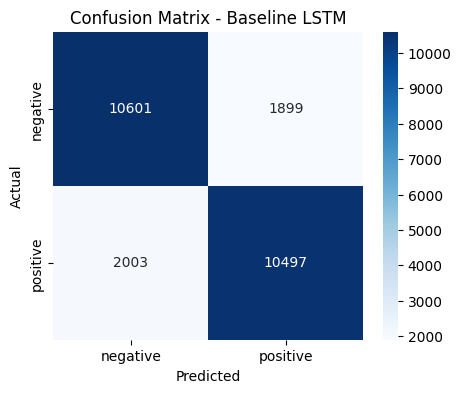

True Negative: 10601 | False Positive: 1899
False Negative: 2003 | True Positive: 10497

→ False Positive (dự đoán positive nhưng thực negative): 1899 ca
→ False Negative (dự đoán negative nhưng thực positive): 2003 ca


In [4]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative","positive"], yticklabels=["negative","positive"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline LSTM")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negative: {tn} | False Positive: {fp}")
print(f"False Negative: {fn} | True Positive: {tp}")
print(f"\n→ False Positive (dự đoán positive nhưng thực negative): {fp} ca")
print(f"→ False Negative (dự đoán negative nhưng thực positive): {fn} ca")


## 3. ROC Curve & AUC

ROC curve cho thấy trade-off giữa True Positive Rate và False Positive Rate ở các ngưỡng threshold khác nhau (không chỉ threshold 0.5 mặc định).

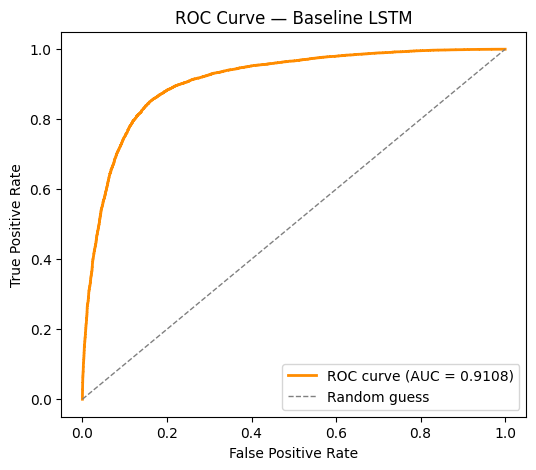

AUC = 0.9108  (1.0 = hoàn hảo, 0.5 = đoán ngẫu nhiên)


In [5]:
fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline LSTM")
plt.legend(loc="lower right")
plt.show()

print(f"AUC = {roc_auc:.4f}  (1.0 = hoàn hảo, 0.5 = đoán ngẫu nhiên)")


## 4. Precision-Recall Curve

Hữu ích để xem model đánh đổi giữa precision và recall như thế nào — đặc biệt quan trọng nếu ứng dụng thực tế ưu tiên 1 trong 2 chỉ số (ví dụ ưu tiên recall nếu không muốn bỏ sót review negative cần xử lý).

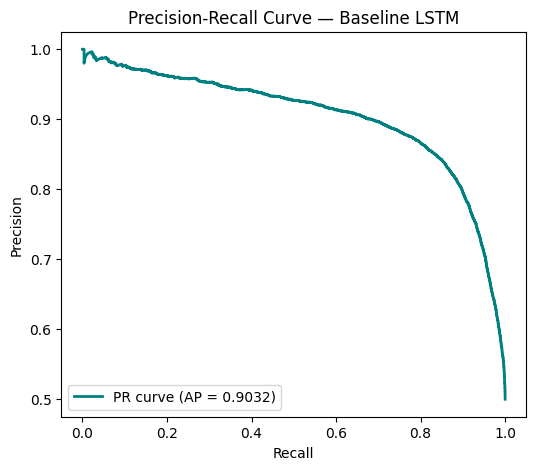

Average Precision (AP) = 0.9032


In [6]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(all_labels, all_probs)
avg_precision = average_precision_score(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve, color="teal", lw=2, label=f"PR curve (AP = {avg_precision:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Baseline LSTM")
plt.legend(loc="lower left")
plt.show()

print(f"Average Precision (AP) = {avg_precision:.4f}")


## 5. Phân tích lỗi theo độ dài review

Câu hỏi: model có dự đoán kém hơn với review quá ngắn (ít thông tin) hay quá dài (khó giữ ngữ cảnh qua LSTM) không?

                mean  count
length_bin                 
0-50        0.877329    644
51-100      0.876538   2519
101-150     0.874855   6880
151-200     0.860804   4878
201-250     0.804346  10079


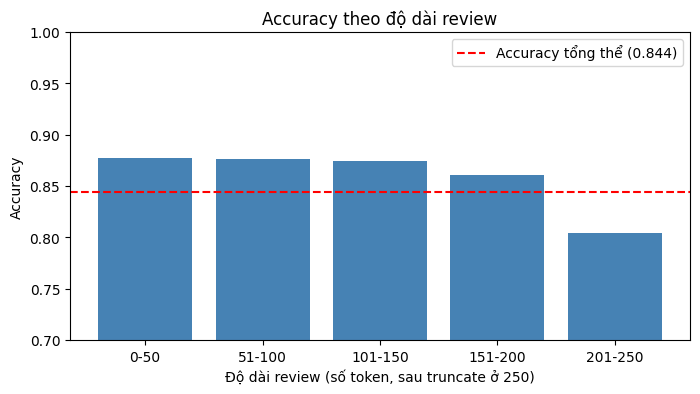


→ Nếu accuracy giảm rõ rệt ở nhóm review ngắn (0-50 token), điều này gợi ý model thiếu thông tin để phán đoán chính xác.
→ Nếu giảm ở nhóm dài (201-250, bị truncate), có thể MAX_LEN=250 đã cắt mất phần quan trọng của review.


In [7]:
length_bins = [0, 50, 100, 150, 200, 250]
bin_labels = ["0-50", "51-100", "101-150", "151-200", "201-250"]

df_analysis = pd.DataFrame({
    "length": all_lengths, "correct": (all_preds == all_labels).astype(int)
})
df_analysis["length_bin"] = pd.cut(df_analysis["length"], bins=length_bins, labels=bin_labels, include_lowest=True)

acc_by_length = df_analysis.groupby("length_bin", observed=True)["correct"].agg(["mean", "count"])
print(acc_by_length)

plt.figure(figsize=(8, 4))
plt.bar(acc_by_length.index.astype(str), acc_by_length["mean"], color="steelblue")
plt.ylim(0.7, 1.0)
plt.ylabel("Accuracy")
plt.xlabel("Độ dài review (số token, sau truncate ở 250)")
plt.title("Accuracy theo độ dài review")
plt.axhline(acc, color="red", linestyle="--", label=f"Accuracy tổng thể ({acc:.3f})")
plt.legend()
plt.show()

print("\n→ Nếu accuracy giảm rõ rệt ở nhóm review ngắn (0-50 token), điều này gợi ý model thiếu thông tin để phán đoán chính xác.")
print("→ Nếu giảm ở nhóm dài (201-250, bị truncate), có thể MAX_LEN=250 đã cắt mất phần quan trọng của review.")


## 6. Top ví dụ dự đoán sai — phân tích nguyên nhân

In [8]:
# Lấy các ca sai có độ tự tin cao nhất (model "sai mà rất chắc chắn") — đáng phân tích nhất
wrong_mask = all_preds != all_labels
wrong_indices = np.where(wrong_mask)[0]

# Độ tự tin = khoảng cách xác suất so với 0.5
confidence = np.abs(all_probs - 0.5)
wrong_confidence = confidence[wrong_indices]
most_confident_wrong = wrong_indices[np.argsort(-wrong_confidence)][:5]

label_map = {0: "negative", 1: "positive"}

print("="*70)
print("TOP 5 CA SAI VỚI ĐỘ TỰ TIN CAO NHẤT (model 'chắc chắn nhưng sai')")
print("="*70)
for idx in most_confident_wrong:
    seq = X_test[idx]
    print(f"\nText: {decode_sequence(seq)}")
    print(f"→ Actual: {label_map[int(all_labels[idx])]} | Predicted: {label_map[int(all_preds[idx])]} "
          f"(prob={all_probs[idx]:.3f}, độ dài={all_lengths[idx]} token)")

print("\n\nNhận xét: các ca này thường là review có yếu tố mỉa mai (sarcasm), pha trộn cảm xúc "
      "(khen 1 phần, chê 1 phần), hoặc dùng từ ngữ trung tính/gián tiếp mà model khó nắm bắt "
      "nếu chỉ dựa vào pattern từ vựng học được từ dữ liệu train.")


TOP 5 CA SAI VỚI ĐỘ TỰ TIN CAO NHẤT (model 'chắc chắn nhưng sai')

Text: this film derives from a long running <unk> sitcom by the same name the sitcom lasted for half a decade roughly and brought to our screens <unk> phillip alan mrs jones vienna then in 1980 the film version hit the cinemas now when it did sadly richard beckinsale had passed away was replaced by only when i laugh actor chris <unk> i myself felt this gave the film a different feel i would have preferred if it wasn't shot as...
→ Actual: negative | Predicted: positive (prob=1.000, độ dài=212 token)

Text: is the boob in the pie every thing else in it is an abortion a <unk> failure of a film at least you can see and hear what goes on in an ed wood movie usually high schools drama clubs do better than this on a routine basis once you've you've seen the breast pie bit you can turn it off and go watch hannibal
→ Actual: negative | Predicted: positive (prob=0.999, độ dài=65 token)

Text: a couple of friends and myself visit

---
### ✅ Kết thúc Giai đoạn 3

Đã có:
- Đánh giá đầy đủ: Accuracy/Precision/Recall/F1, Confusion Matrix
- ROC Curve (AUC) và Precision-Recall Curve — đánh giá model ở nhiều ngưỡng threshold, không chỉ 0.5
- Phân tích accuracy theo độ dài review — kiểm tra điểm yếu tiềm ẩn liên quan đến MAX_LEN
- Top ví dụ dự đoán sai với độ tự tin cao nhất — điểm khởi đầu tốt để phân tích giới hạn của model trong báo cáo

**Bước tiếp theo (Giai đoạn 4):** huấn luyện các model mở rộng (GRU, Bidirectional LSTM, GloVe) để so sánh với baseline.
